# Notebook 4: Model Configuration & Training

**Goal:** Configure SegResNet, understand its architecture, run training interactively with full visibility into loss curves and validation metrics.

## What we'll cover:
1. SegResNet architecture overview
2. Model instantiation and parameter counting
3. Forward pass test (single patch)
4. Loss function setup (DiceCE)
5. Training loop (interactive, epoch-by-epoch)
6. Validation with sliding window inference
7. Monitoring: loss curves, learning rate schedule

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import yaml

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.segresnet import empty_cache, get_device

# Device setup — auto-detects best available: MPS > CUDA > CPU
device = get_device()
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")

/home/l091835/cns_vnv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0+cu130
Device:  cpu


## 1. SegResNet Architecture

**SegResNet** (from MONAI) is an encoder-decoder with:
- Residual blocks in each resolution stage
- Progressive downsampling (encoder) then upsampling (decoder)
- Skip connections between encoder and decoder
- Dropout for uncertainty estimation (Phase 3)

```
Input [1, 48, 160, 160]
  │
  ├── Encoder: 32→64→128→256 filters, blocks_down=[1,2,2,4]
  │     (each stage: stride-2 conv + N residual blocks)
  │
  ├── Bottleneck: 256 filters, 4 residual blocks
  │
  ├── Decoder: 256→128→64→32 filters, blocks_up=[1,1,1]
  │     (each stage: upsample + concat skip + N residual blocks)
  │
  └── Head: 1×1 conv → 2 channels (background + cord)
       Output [2, 48, 160, 160]
```

In [2]:
from src.models.segresnet import create_segresnet, count_parameters

# Model configuration (from configs/train_spine.yaml)
model_config = {
    "architecture": "SegResNet",
    "spatial_dims": 3,
    "in_channels": 1,        # single MRI contrast (T2w)
    "out_channels": 2,       # background + spinal cord
    "init_filters": 32,      # first layer channels
    "blocks_down": [1, 2, 2, 4],  # residual blocks per encoder stage
    "blocks_up": [1, 1, 1],       # residual blocks per decoder stage
    "dropout_prob": 0.2,     # for MC-Dropout in Phase 3
}

model = create_segresnet(model_config)
print(f"Model created with configuration: {model_config}")
print(f"Model details: {model}")
model = model.to(device)

n_params = count_parameters(model)
print(f"\nModel: SegResNet")
print(f"Parameters: {n_params:,} ({n_params/1e6:.2f}M)")
print(f"Device: {device}")

Model created with configuration: {'architecture': 'SegResNet', 'spatial_dims': 3, 'in_channels': 1, 'out_channels': 2, 'init_filters': 32, 'blocks_down': [1, 2, 2, 4], 'blocks_up': [1, 1, 1], 'dropout_prob': 0.2}
Model details: SegResNet(
  (act_mod): ReLU(inplace=True)
  (convInit): Convolution(
    (conv): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  )
  (down_layers): ModuleList(
    (0): Sequential(
      (0): Identity()
      (1): ResBlock(
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
        (norm2): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
        (act): ReLU(inplace=True)
        (conv1): Convolution(
          (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
        (conv2): Convolution(
          (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
      )
    )
    (1): Sequential(
      (0)

In [3]:
# Print model structure
print(model)

SegResNet(
  (act_mod): ReLU(inplace=True)
  (convInit): Convolution(
    (conv): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  )
  (down_layers): ModuleList(
    (0): Sequential(
      (0): Identity()
      (1): ResBlock(
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
        (norm2): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
        (act): ReLU(inplace=True)
        (conv1): Convolution(
          (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
        (conv2): Convolution(
          (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
      )
    )
    (1): Sequential(
      (0): Convolution(
        (conv): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (1): ResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
        (norm

## 2. Forward Pass Test

Verify the model can process a patch of the expected shape.

In [4]:
# Create a synthetic input matching our patch size
PATCH_SIZE = [48, 160, 160]
BATCH_SIZE = 2

# Dummy input: [batch, channels, depth, height, width]
dummy_input = torch.randn(BATCH_SIZE, 1, *PATCH_SIZE).to(device)
print(f"Input shape:  {list(dummy_input.shape)}")

# Forward pass
model.eval()
with torch.no_grad():
    t0 = time.time()
    output = model(dummy_input)
    t1 = time.time()

print(f"Output shape: {list(output.shape)}")
print(f"Forward time: {(t1-t0)*1000:.1f} ms")
print(f"\nOutput range: [{output.min():.3f}, {output.max():.3f}]")
print(f"(Raw logits — need softmax for probabilities)")

# Apply softmax to get probabilities
probs = torch.softmax(output, dim=1)
print(f"\nSoftmax probs sum: {probs[0, :, 24, 80, 80].sum():.4f} (should be 1.0)")
print(f"Class 0 (background) prob: {probs[0, 0, 24, 80, 80]:.4f}")
print(f"Class 1 (cord) prob:       {probs[0, 1, 24, 80, 80]:.4f}")

Input shape:  [2, 1, 48, 160, 160]
Output shape: [2, 2, 48, 160, 160]
Forward time: 8148.4 ms

Output range: [-2.371, 1.791]
(Raw logits — need softmax for probabilities)

Softmax probs sum: 1.0000 (should be 1.0)
Class 0 (background) prob: 0.7416
Class 1 (cord) prob:       0.2584


## 3. Loss Function: DiceCE

**DiceCELoss** combines:
- **Dice Loss:** Directly optimizes the Dice metric (overlap between pred and GT)
- **Cross-Entropy:** Provides stable gradients, especially early in training

Parameters:
- `include_background=False`: Don't include the background class in Dice
- `to_onehot_y=True`: Convert integer labels to one-hot
- `softmax=True`: Apply softmax to model output

In [5]:
from monai.losses import DiceCELoss

loss_fn = DiceCELoss(
    include_background=False,
    to_onehot_y=True,
    softmax=True,
)

# Test loss computation
# Simulate a label (integer class indices)
dummy_label = torch.zeros(BATCH_SIZE, 1, *PATCH_SIZE, dtype=torch.long).to(device)
# Put some "cord" in the center
dummy_label[:, :, 20:28, 75:85, 75:85] = 1

model.train()
pred = model(dummy_input)
loss = loss_fn(pred, dummy_label)

print(f"DiceCE Loss: {loss.item():.4f}")
print(f"\nWith random initialization, loss starts high (~1.0-1.5).")
print(f"Target: should decrease to < 0.1 after training.")

DiceCE Loss: 1.4749

With random initialization, loss starts high (~1.0-1.5).
Target: should decrease to < 0.1 after training.


## 4. Optimizer & Scheduler

- **AdamW** (lr=1e-4, weight_decay=1e-5): stable, works well for medical imaging
- **CosineAnnealingLR**: gradually decays lr following a cosine curve

Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate


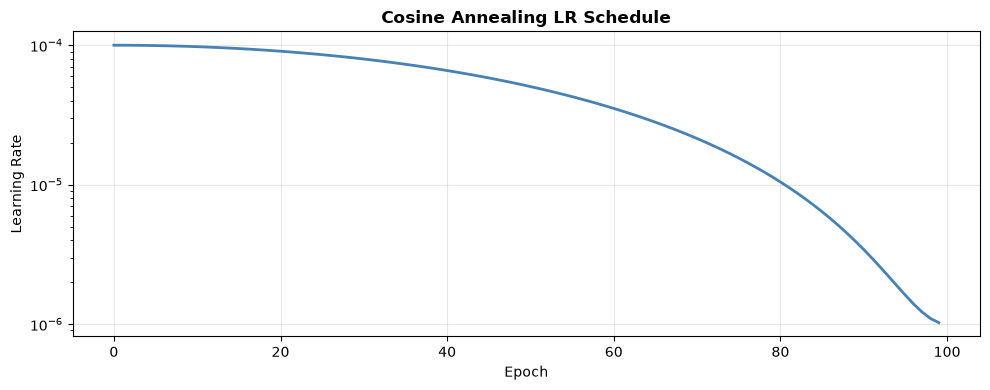

Start LR: 1.00e-04
End LR:   1.02e-06


In [6]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS = 100
LR = 1e-4

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Visualize learning rate schedule
lrs = []
for epoch in range(EPOCHS):
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

plt.figure(figsize=(10, 4))
plt.plot(lrs, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Cosine Annealing LR Schedule', fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Start LR: {lrs[0]:.2e}")
print(f"End LR:   {lrs[-1]:.2e}")

# Reset for actual training
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

## 5. Data Loading (for actual training)

Let's set up the actual data pipeline.

In [ ]:
from monai.data import CacheDataset, DataLoader
from src.data.spine_generic import create_datalist
from src.data.transforms import get_train_transforms, get_val_transforms

# Load config
with open(PROJECT_ROOT / "configs" / "train_spine.yaml") as f:
    config = yaml.safe_load(f)

DATA_ROOT = PROJECT_ROOT / config['data']['root_dir']
train_sites = config['data']['train_sites']
val_sites = config['data']['val_sites']

# Get datalists
train_files = create_datalist(root_dir=DATA_ROOT, sites=train_sites)
val_files = create_datalist(root_dir=DATA_ROOT, sites=val_sites)

print(f"Training volumes: {len(train_files)}")
print(f"Validation volumes: {len(val_files)}")

if len(train_files) == 0:
    print("\n⚠️  No training data! Labels are likely git-annex stubs.")
    print("   Run: bash scripts/setup_data.sh")
    print("   Then restart this notebook.")

Skipping subject with unparseable ID: sub-juntendo750w01
Skipping subject with unparseable ID: sub-juntendo750w02
Skipping subject with unparseable ID: sub-juntendo750w03
Skipping subject with unparseable ID: sub-juntendo750w04
Skipping subject with unparseable ID: sub-juntendo750w05
Skipping subject with unparseable ID: sub-juntendo750w06
Skipping subject with unparseable ID: sub-tokyo750w01
Skipping subject with unparseable ID: sub-tokyo750w02
Skipping subject with unparseable ID: sub-tokyo750w03
Skipping subject with unparseable ID: sub-tokyo750w04
Skipping subject with unparseable ID: sub-tokyo750w05
Skipping subject with unparseable ID: sub-tokyo750w06
Skipping subject with unparseable ID: sub-tokyo750w07
Skipping subject with unparseable ID: sub-juntendo750w01
Skipping subject with unparseable ID: sub-juntendo750w02
Skipping subject with unparseable ID: sub-juntendo750w03
Skipping subject with unparseable ID: sub-juntendo750w04
Skipping subject with unparseable ID: sub-juntendo75

Training volumes: 78
Validation volumes: 32


: 

In [ ]:
# Only proceed if we have data
if len(train_files) > 0:
    transform_config = {
        "spacing": config['preprocessing']['spacing'],
        "patch_size": config['training']['patch_size'],
        "num_samples": config['training']['num_samples'],
    }
    
    train_transforms = get_train_transforms(transform_config)
    val_transforms = get_val_transforms(transform_config)
    
    # Use CacheDataset with reduced cache_rate to save unified memory for MPS
    # (On Apple Silicon, CPU RAM and GPU share the same physical memory pool)
    train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=0.5)
    val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=0.5)
    
    # batch_size=1 here — we use gradient accumulation in the training loop
    # to achieve effective batch_size=2 without doubling activation memory
    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)
    
    print(f"Train loader: {len(train_loader)} batches (batch_size=1, grad accum=2)")
    print(f"Val loader:   {len(val_loader)} batches")
else:
    print("Skipping dataloader creation (no data).")
    train_loader = None
    val_loader = None

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
Loading dataset:   0%|          | 0/39 [00:00<?, ?it/s]

## 6. Training Loop (Interactive)

Train epoch-by-epoch with full visibility. You can stop early with Kernel → Interrupt.

In [ ]:
from monai.inferers import SlidingWindowInferer
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete, Compose as MonaiCompose
from monai.data import decollate_batch

# Training settings
NUM_EPOCHS = 30  # start small, increase if it's working
VAL_INTERVAL = 5
ACCUM_STEPS = 2  # gradient accumulation → effective batch size = 1 * 2 = 2

# Tracking
train_losses = []
val_dices = []
val_epochs = []
best_dice = -1
best_epoch = -1

# Post-processing for metrics
post_pred = MonaiCompose([AsDiscrete(argmax=True, to_onehot=2)])
post_label = MonaiCompose([AsDiscrete(to_onehot=2)])
dice_metric = DiceMetric(include_background=False, reduction="mean")

# Sliding window inferer for validation — sw_batch_size=1 to limit peak memory
inferer = SlidingWindowInferer(
    roi_size=PATCH_SIZE, overlap=0.5, mode="gaussian", sw_batch_size=1
)

print(f"Training for {NUM_EPOCHS} epochs (validate every {VAL_INTERVAL})")
print(f"Gradient accumulation: {ACCUM_STEPS} steps (effective batch_size={ACCUM_STEPS})")
print(f"{'='*60}")

if train_loader is not None:
    # Reset model and optimizer
    model = create_segresnet(model_config).to(device)
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    
    for epoch in range(NUM_EPOCHS):
        # --- Training ---
        model.train()
        epoch_loss = 0
        n_steps = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            inputs = batch["image"].to(device)
            labels = batch["label"].to(device)
            
            outputs = model(inputs)
            loss = loss_fn(outputs, labels) / ACCUM_STEPS
            loss.backward()
            
            # Step optimizer every ACCUM_STEPS or at end of epoch
            if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad()
            
            epoch_loss += loss.item() * ACCUM_STEPS  # un-scale for logging
            n_steps += 1
            
            # Free accelerator memory between steps (no-op on CPU)
            del inputs, labels, outputs, loss
            empty_cache(device)
        
        scheduler.step()
        avg_loss = epoch_loss / max(n_steps, 1)
        train_losses.append(avg_loss)
        
        # --- Validation ---
        if (epoch + 1) % VAL_INTERVAL == 0:
            model.eval()
            with torch.no_grad():
                for val_batch in val_loader:
                    val_inputs = val_batch["image"].to(device)
                    val_labels = val_batch["label"].to(device)
                    val_outputs = inferer(val_inputs, model)
                    
                    # Move to CPU immediately to free accelerator memory
                    val_outputs_list = decollate_batch(val_outputs.cpu())
                    val_labels_list = decollate_batch(val_labels.cpu())
                    val_outputs_post = [post_pred(i) for i in val_outputs_list]
                    val_labels_post = [post_label(i) for i in val_labels_list]
                    dice_metric(y_pred=val_outputs_post, y=val_labels_post)
                    
                    del val_inputs, val_labels, val_outputs
                    empty_cache(device)
            
            val_dice = dice_metric.aggregate().item()
            dice_metric.reset()
            val_dices.append(val_dice)
            val_epochs.append(epoch + 1)
            
            if val_dice > best_dice:
                best_dice = val_dice
                best_epoch = epoch + 1
                marker = " ★ NEW BEST"
            else:
                marker = ""
            
            print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | loss={avg_loss:.4f} | "
                  f"val_dice={val_dice:.4f} | best={best_dice:.4f}@{best_epoch}{marker}")
        else:
            print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | loss={avg_loss:.4f}")
    
    print(f"\n{'='*60}")
    print(f"Training complete! Best Dice: {best_dice:.4f} at epoch {best_epoch}")
else:
    print("⚠️  No data available. Fix data setup first (bash scripts/setup_data.sh).")

## 7. Training Curves

In [ ]:
if len(train_losses) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curve
    axes[0].plot(range(1, len(train_losses)+1), train_losses, 'b-', linewidth=1.5, label='Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('DiceCE Loss')
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Validation Dice
    if len(val_dices) > 0:
        axes[1].plot(val_epochs, val_dices, 'ro-', linewidth=2, markersize=8, label='Val Dice')
        axes[1].axhline(y=0.93, color='green', linestyle='--', alpha=0.7, label='Target (0.93)')
        if best_dice > 0:
            axes[1].axhline(y=best_dice, color='red', linestyle=':', alpha=0.5, 
                           label=f'Best ({best_dice:.4f})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].set_title('Validation Dice', fontweight='bold')
    axes[1].set_ylim([0, 1])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('Training Progress', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No training data to plot.")

## 8. Visualize Predictions

Let's look at what the model actually predicts on a validation case.

In [ ]:
if val_loader is not None and len(val_dices) > 0:
    model.eval()
    with torch.no_grad():
        val_batch = next(iter(val_loader))
        val_input = val_batch["image"].to(device)
        val_label = val_batch["label"].to(device)
        val_pred = inferer(val_input, model)
        
        # Get predicted class
        pred_class = val_pred.argmax(dim=1)[0].cpu().numpy()
        img_np = val_input[0, 0].cpu().numpy()
        lbl_np = val_label[0, 0].cpu().numpy()
    
    # Find a slice with label content
    label_sum = lbl_np.sum(axis=(0, 1))
    best_slice = np.argmax(label_sum)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(img_np[:, :, best_slice].T, cmap='gray', origin='lower')
    axes[0].set_title('Input MRI')
    axes[0].axis('off')
    
    axes[1].imshow(lbl_np[:, :, best_slice].T, cmap='Reds', origin='lower')
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')
    
    axes[2].imshow(pred_class[:, :, best_slice].T, cmap='Blues', origin='lower')
    axes[2].set_title('Prediction')
    axes[2].axis('off')
    
    # Overlay comparison
    axes[3].imshow(img_np[:, :, best_slice].T, cmap='gray', origin='lower')
    gt_mask = np.ma.masked_where(lbl_np[:, :, best_slice].T == 0, lbl_np[:, :, best_slice].T)
    pred_mask = np.ma.masked_where(pred_class[:, :, best_slice].T == 0, pred_class[:, :, best_slice].T)
    axes[3].imshow(gt_mask, cmap='Greens', alpha=0.5, origin='lower')
    axes[3].imshow(pred_mask, cmap='Reds', alpha=0.3, origin='lower')
    axes[3].set_title('Green=GT, Red=Pred')
    axes[3].axis('off')
    
    plt.suptitle(f'Validation Prediction (Dice={val_dices[-1]:.4f})', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No predictions to visualize (training didn't run).")

## 9. Save Model Checkpoint

In [ ]:
if best_dice > 0:
    save_dir = PROJECT_ROOT / "experiments" / "notebook_training"
    save_dir.mkdir(parents=True, exist_ok=True)
    
    checkpoint = {
        "model_state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
        "best_dice": best_dice,
        "best_epoch": best_epoch,
        "model_config": model_config,
        "train_losses": train_losses,
        "val_dices": val_dices,
    }
    
    save_path = save_dir / "best_model.pth"
    torch.save(checkpoint, save_path)
    print(f"Model saved to: {save_path}")
    print(f"Best Dice: {best_dice:.4f} at epoch {best_epoch}")
else:
    print("No model to save (training didn't complete).")

## Summary

| Component | Choice | Why |
|-----------|--------|-----|
| Architecture | SegResNet 3D | Light, fast, MONAI-native |
| Parameters | ~4.7M | Fits comfortably on MPS/CUDA/CPU |
| Loss | DiceCE | Dice for overlap + CE for gradient stability |
| Optimizer | AdamW (lr=1e-4) | Standard for medical imaging |
| Scheduler | CosineAnnealing | Smooth decay, no sudden drops |
| Patch size | [48, 160, 160] | Covers cord cross-section |
| Validation | Sliding window (overlap=0.5) | Full volume inference |
| Device | Auto-detect (`get_device()`) | MPS > CUDA > CPU, whichever is best available |

**To run full training** (100 epochs with all data):  
```bash
python scripts/train.py --config configs/train_spine.yaml
```